In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time
import copy
import os
import pickle
from collections import Counter
from sklearn.metrics import log_loss

import import_ipynb
import importlib
import functions as fc
importlib.reload(fc)

print(os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


/Users/elif/Desktop/Projects/privacy_in_ml/jupyter_notebooks


In [2]:
diabetes_train = pd.read_csv("../datasets/diabetes_train_balanced.csv")
diabetes_test = pd.read_csv("../datasets/diabetes_test.csv")

----------------------------------------------------------------------------------------------
-------------------------------------- ORIGINAL DATASET --------------------------------------
----------------------------------------------------------------------------------------------

In [3]:
X_train = diabetes_train.drop('Outcome', axis = 1)
X_test = diabetes_test.drop('Outcome', axis = 1)
y_train = diabetes_train['Outcome']
y_test = diabetes_test['Outcome']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### Fit the model

In [4]:
#Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None
model = LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Prediction and utility

In [5]:
print("Training set: ")
fc.predict_binary(model, X_train_sc, y_train, conf_matrix=False)


Training set: 
---------------------------------------
Accuracy: 0.7581
Precision: 0.7717
Recall: 0.7332
F1 Score: 0.7519
---------------------------------------


---------------------------------------
Accuracy: 0.7078
Precision: 0.5735
Recall: 0.7091
F1 Score: 0.6341
---------------------------------------
          Predicted 0  Predicted 1
Actual 0           70           29
Actual 1           16           39


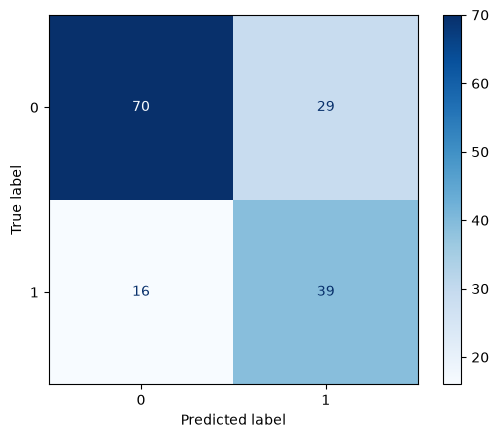

Saved results to ../results/model_results_diabetes.xlsx


In [6]:
fc.predict_binary_save_results(
    model,
    X_test_sc,
    y_test,
    conf_matrix = True,
    perturbation_type="Original_balanced",
    epsilon=0,
    output_file="../results/model_results_diabetes.xlsx"
)


In [7]:
fc.cross_validate_model(model, X_train_sc, y_train, cv=10, bivariate = True)

Accuracy: 0.7556
Precision: 0.7656
Recall: 0.7380
F1 Score: 0.7501
Time: 0.027987003326416016


{'fit_time': array([0.00118279, 0.00078416, 0.00074601, 0.000736  , 0.00088811,
        0.00074506, 0.00072193, 0.00072217, 0.00068402, 0.00076222]),
 'score_time': array([0.00192595, 0.00178099, 0.00182772, 0.0019691 , 0.0017612 ,
        0.00174189, 0.00178313, 0.00178289, 0.00182509, 0.00191903]),
 'test_accuracy': array([0.72839506, 0.80246914, 0.75      , 0.725     , 0.7375    ,
        0.7375    , 0.725     , 0.7375    , 0.85      , 0.7625    ]),
 'test_precision': array([0.75      , 0.80487805, 0.79411765, 0.725     , 0.74358974,
        0.73170732, 0.78125   , 0.73170732, 0.85      , 0.74418605]),
 'test_recall': array([0.675     , 0.80487805, 0.675     , 0.725     , 0.725     ,
        0.75      , 0.625     , 0.75      , 0.85      , 0.8       ]),
 'test_f1': array([0.71052632, 0.80487805, 0.72972973, 0.725     , 0.73417722,
        0.74074074, 0.69444444, 0.74074074, 0.85      , 0.77108434])}

In [8]:
fc.hyperparameterTuning_save_Results(X_train_sc, y_train, cv=10, bivariate = True, perturbation_type="Original_hpt_balanced",
        epsilon=0, output_file="../results/model_results_diabetes.xlsx")

Best parameters: {'C': 0.1}
Accuracy : 0.7581
Precision: 0.7700
Recall   : 0.7379
F1 Score : 0.7521
Time     : 1.90 s


(LogisticRegression(C=0.1, max_iter=1000), {'C': 0.1})

In [9]:
X_all = pd.concat([X_train, X_test], axis=0)
orig_confidence_scores = model.predict_proba(X_all)

with open("orig_confidence_scores_diabetes_balanced.pkl", "wb") as f:
    pickle.dump(orig_confidence_scores, f)

/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

### Perturb dataset

In [10]:
# Define ranges
ranges = [[0,20], [40,300], [30,200], [5,100], [2,900], [10,70], [0,3], [21,100]]
print(ranges)
sensitivity = []
for range in ranges:
    sensitivity.append(range[1]-range[0])
print(sensitivity)

[[0, 20], [40, 300], [30, 200], [5, 100], [2, 900], [10, 70], [0, 3], [21, 100]]
[20, 260, 170, 95, 898, 60, 3, 79]


In [11]:
epsilon_values = [0.01, 0.1, 1, 5, 10, 30, 50, 100]
perturbed_datasets = {}

np.random.seed(42)
for e in epsilon_values:
    X_train_perturbed = X_train.copy()
    d = X_train_perturbed.shape[1]

    for i, var in enumerate(X_train.columns):
        eps_j = e/d 
        scale = sensitivity[i] / eps_j   
        noise = np.random.laplace(loc=0,scale=scale,size=len(X_train))

        lower, upper = ranges[i]
        X_train_perturbed[var] = (
            X_train[var] + noise
        ).clip(lower=lower, upper=upper)

    perturbed_datasets[e] = X_train_perturbed

### Fit the model with the new datasets

In [12]:
input_confidence_scores = {}

for e in epsilon_values:
    input_model = copy.deepcopy(model)

    X_train_input = perturbed_datasets[e]
    scaler = StandardScaler()
    X_train_input_sc = scaler.fit_transform(X_train_input)
    X_test_input_sc = scaler.transform(X_test)

    input_model.fit(X_train_input_sc, y_train)

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(input_model, X_train_input_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        input_model,
        X_test_input_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Input_balanced",
        epsilon=e,
        output_file="../results/model_results_diabetes.xlsx"
    )

    fc.hyperparameterTuning_save_Results(X_train_input_sc, y_train, cv=10, bivariate = True, perturbation_type="Input_hpt_balanced",
        epsilon=e, output_file="../results/model_results_diabetes.xlsx")


    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train, X_test], axis=0)
    input_confidence_scores[e] = input_model.predict_proba(X_all)

with open("../results/input_confidence_scores_diabetes_balanced.pkl", "wb") as f:
    pickle.dump(input_confidence_scores, f)


Training set: 
---------------------------------------
Accuracy: 0.5449
Precision: 0.5450
Recall: 0.5436
F1 Score: 0.5443
---------------------------------------
---------------------------------------
Accuracy: 0.3571
Precision: 0.2925
Recall: 0.5636
F1 Score: 0.3851
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.5051
Precision: 0.5071
Recall   : 0.4913
F1 Score : 0.4980
Time     : 0.05 s
Training set: 
---------------------------------------
Accuracy: 0.5549
Precision: 0.5537
Recall: 0.5661
F1 Score: 0.5598
---------------------------------------
---------------------------------------
Accuracy: 0.3636
Precision: 0.3557
Recall: 0.9636
F1 Score: 0.5196
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx


/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Best parameters: {'C': 0.01}
Accuracy : 0.5236
Precision: 0.5248
Recall   : 0.5383
F1 Score : 0.5297
Time     : 0.05 s


/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Training set: 
---------------------------------------
Accuracy: 0.5586
Precision: 0.5569
Recall: 0.5736
F1 Score: 0.5651
---------------------------------------
---------------------------------------
Accuracy: 0.5844
Precision: 0.4082
Recall: 0.3636
F1 Score: 0.3846
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.5126
Precision: 0.5134
Recall   : 0.4990
F1 Score : 0.5043
Time     : 0.04 s
Training set: 
---------------------------------------
Accuracy: 0.5374
Precision: 0.5379
Recall: 0.5312
F1 Score: 0.5345
---------------------------------------
---------------------------------------
Accuracy: 0.6558
Precision: 0.5625
Recall: 0.1636
F1 Score: 0.2535
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx
Best parameters: {'C': 0.1}
Accuracy : 0.5087
Precision: 0.5081
Recall   : 0.5062
F1 Score : 0.5048
Time     : 0.05 s
Training set: 
------------------

/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to ../results/model_results_diabetes.xlsx


/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Best parameters: {'C': 0.1}
Accuracy : 0.5327
Precision: 0.5339
Recall   : 0.5016
F1 Score : 0.5152
Time     : 0.04 s
Training set: 
---------------------------------------
Accuracy: 0.5998
Precision: 0.6053
Recall: 0.5736
F1 Score: 0.5890
---------------------------------------
---------------------------------------
Accuracy: 0.7338
Precision: 0.6522
Recall: 0.5455
F1 Score: 0.5941
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx
Best parameters: {'C': 1}
Accuracy : 0.5822
Precision: 0.5877
Recall   : 0.5659
F1 Score : 0.5750
Time     : 0.05 s
Training set: 
---------------------------------------
Accuracy: 0.6771
Precision: 0.6784
Recall: 0.6733
F1 Score: 0.6758
---------------------------------------
---------------------------------------
Accuracy: 0.7078
Precision: 0.5806
Recall: 0.6545
F1 Score: 0.6154
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx
Best parameters: {'C': 0.01}
Accurac

/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to ../results/model_results_diabetes.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.7033
Precision: 0.7160
Recall   : 0.6834
F1 Score : 0.6972
Time     : 0.05 s


/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [13]:
n = X_train.shape[0]
C_x = np.max(np.linalg.norm(X_train_sc, axis=1))
lambda_reg = 1 / model.C
sensitivity = (C_x*2) / (lambda_reg * n)

epsilon_values = [0.01, 0.1, 1, 5, 10, 30, 50, 100]
perturbed_coefficients = {}

np.random.seed(42)
for e in epsilon_values:
    coef_noise = np.random.laplace(loc=0,scale=sensitivity/e, size=model.coef_.shape)
    intercept_noise = np.random.laplace(loc=0,scale=sensitivity /e, size=model.intercept_.shape)
    perturbed_coefficients[e] = {
        "coef": model.coef_ + coef_noise,
        "intercept": model.intercept_ + intercept_noise
    }

In [14]:
output_confidence_scores = {}

for e in epsilon_values:
    output_model = copy.deepcopy(model)

    output_model.coef_ = perturbed_coefficients[e]["coef"]
    output_model.intercept_ = perturbed_coefficients[e]["intercept"]

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(output_model, X_train_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        output_model,
        X_test_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Output_balanced",
        epsilon=e,
        output_file="../results/model_results_diabetes.xlsx"
    )

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train, X_test], axis=0)
    output_confidence_scores[e] = output_model.predict_proba(X_all)

with open("output_confidence_scores_diabetes_balanced.pkl", "wb") as f:
    pickle.dump(output_confidence_scores, f)

Training set: 
---------------------------------------
Accuracy: 0.6434
Precision: 0.6420
Recall: 0.6484
F1 Score: 0.6452
---------------------------------------
---------------------------------------
Accuracy: 0.6104
Precision: 0.4603
Recall: 0.5273
F1 Score: 0.4915
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7095
Precision: 0.7100
Recall: 0.7082
F1 Score: 0.7091
---------------------------------------
---------------------------------------
Accuracy: 0.6883
Precision: 0.5479
Recall: 0.7273
F1 Score: 0.6250
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7569
Precision: 0.7725
Recall: 0.7282
F1 Score: 0.7497
---------------------------------------
---------------------------------------
Accuracy: 0.7078
Precision: 0.5735
Recall: 0.7091
F1 Score: 0.6341
-

/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to ../results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7569
Precision: 0.7696
Recall: 0.7332
F1 Score: 0.7510
---------------------------------------
---------------------------------------
Accuracy: 0.7078
Precision: 0.5735
Recall: 0.7091
F1 Score: 0.6341
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7581
Precision: 0.7702
Recall: 0.7357
F1 Score: 0.7526
---------------------------------------
---------------------------------------
Accuracy: 0.7078
Precision: 0.5735
Recall: 0.7091
F1 Score: 0.6341
---------------------------------------


/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to ../results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7581
Precision: 0.7717
Recall: 0.7332
F1 Score: 0.7519
---------------------------------------
---------------------------------------
Accuracy: 0.7078
Precision: 0.5735
Recall: 0.7091
F1 Score: 0.6341
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx
Training set: 
---------------------------------------
Accuracy: 0.7581
Precision: 0.7717
Recall: 0.7332
F1 Score: 0.7519
---------------------------------------
---------------------------------------
Accuracy: 0.7078
Precision: 0.5735
Recall: 0.7091
F1 Score: 0.6341
---------------------------------------
Saved results to ../results/model_results_diabetes.xlsx


/Users/elif/Desktop/Projects/privacy_in_ml/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------

In [15]:
data_norm = np.max(np.linalg.norm(X_train_sc, axis=1))
print("data_norm :", data_norm) #(max L2 norm of a scaled training row)

data_norm : 8.381499661996164


In [16]:
epsilon_values = [0.01, 0.1, 1, 5, 10, 30, 50, 100]

internal_models = fc.internal_perturbation_save_results(
    "diabetes",
    X_train_sc,
    y_train,
    X_test_sc,
    y_test,
    epsilon_values=epsilon_values,
    data_norm=data_norm,
    C=model.C,
    bivariate=True,
    output_file="../results/model_results_diabetes.xlsx",
    perturbation_type="Internal_balanced"
)


---------------------------------------
Epsilon: 0.01
Accuracy: 0.5130
Precision: 0.3780
Recall: 0.5636
F1 Score: 0.4526
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 0.1
Accuracy: 0.5390
Precision: 0.4024
Recall: 0.6000
F1 Score: 0.4818
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 1
Accuracy: 0.6299
Precision: 0.4878
Recall: 0.7273
F1 Score: 0.5839
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 5
Accuracy: 0.7013
Precision: 0.5616
Recall: 0.7455
F1 Score: 0.6406
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 10
Accuracy: 0.6948
Precision: 0.5556
Recall: 0.7273
F1 Score: 0.6299
Time: 0.00 s
---------------------------------------
---------------------------------------
Epsilon: 30
Accuracy: 0.7143
Precision: 0.5821
Recall: 0.7091
F1 Score: 0.6393
Time: 0.00 s
-------